<a href="https://colab.research.google.com/github/lliieth/gpt-from-scrath/blob/main/CyberSec_GPT_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# Cell 1: Setup
# ============================================
!pip -q install torch matplotlib tqdm pandas

import os
import re
import json
import math
import random
import shutil
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

ROOT = Path("/content/gpt-from-scratch-cyber-ar")
for p in [
    ROOT / "data" / "pretrain",
    ROOT / "data" / "finetune",
    ROOT / "src" / "model",
    ROOT / "src" / "tokenizer",
    ROOT / "src" / "training",
    ROOT / "src" / "evaluation",
    ROOT / "checkpoints" / "pretrained",
    ROOT / "checkpoints" / "finetuned",
    ROOT / "results" / "plots",
    ROOT / "results" / "sample_generations",
    ROOT / "demo" / "recording",
    ROOT / "demo" / "screenshots",
    ROOT / "notebooks"
]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)

Device: cuda
Project root: /content/gpt-from-scratch-cyber-ar


In [ ]:
# ============================================
# Cell 2: Generate datasets
# ============================================
arabic_terms = [
    "الأمن السيبراني", "أمن المعلومات", "إدارة الثغرات", "اختبار الاختراق",
    "التحقق متعدد العوامل", "التشفير", "الاستجابة للحوادث", "سجلات النظام",
    "تحليل المخاطر", "أمن الشبكات", "الأمن السحابي", "تحليل البرمجيات الخبيثة",
    "الهندسة الاجتماعية", "كشف التسلل", "إدارة الهوية", "سياسات الأمن",
    "التوعية الأمنية", "الأدلة الجنائية الرقمية", "مركز العمليات الأمنية", "حماية البيانات"
]

threats = [
    "التصيد الاحتيالي", "برامج الفدية", "تسريب البيانات", "اختراق الحسابات",
    "تنفيذ أوامر عن بعد", "الحركة الجانبية", "زرع باب خلفي", "سرقة كلمات المرور",
    "رفع الصلاحيات", "حقن الأوامر", "البرمجيات الضارة", "هجمات القوة الغاشمة"
]

tools = [
    "SIEM", "IDS", "IPS", "EDR", "XDR", "WAF", "VPN", "DLP", "MFA", "SOC"
]

actions = [
    "يحمي", "يعزز", "يكشف", "يقلل", "يمنع", "يراقب", "يوثق",
    "يحلل", "يدعم", "يحسن", "يعالج", "يقيّم", "يختبر"
]

objects_ = [
    "سرية البيانات", "سلامة الأنظمة", "توفر الخدمات", "حركة المرور",
    "سلوك المستخدم", "سطح الهجوم", "ملفات السجل", "الخوادم",
    "الشبكات الداخلية", "طلبات الوصول", "الحسابات الحساسة", "الأجهزة الطرفية"
]

best_practices = [
    "استخدم كلمات مرور قوية وفريدة لكل حساب.",
    "فعّل التحقق متعدد العوامل للحسابات الحساسة.",
    "حدّث الأنظمة والتطبيقات بشكل دوري.",
    "راجع السجلات لاكتشاف الأنشطة غير الطبيعية.",
    "طبّق مبدأ أقل صلاحية على المستخدمين والخدمات.",
    "احتفظ بنسخ احتياطية مشفرة ومنفصلة.",
    "درّب الموظفين على اكتشاف رسائل التصيد.",
    "قسّم الشبكة لتقليل الحركة الجانبية.",
    "أغلق المنافذ والخدمات غير الضرورية.",
    "اختبر الاستعادة من النسخ الاحتياطية باستمرار."
]

qa_pairs = [
    ("ما هو التصيد الاحتيالي؟", "التصيد الاحتيالي أسلوب خداعي يهدف إلى سرقة المعلومات الحساسة عبر رسائل أو صفحات مزيفة."),
    ("ما أهمية التشفير؟", "التشفير يحمي سرية البيانات أثناء النقل والتخزين ويقلل من خطر الاطلاع غير المصرح به."),
    ("كيف أحمي بريدي الإلكتروني؟", "استخدم كلمة مرور قوية وفعّل التحقق متعدد العوامل وتجنب الروابط والمرفقات المشبوهة."),
    ("ما الفرق بين IDS و IPS؟", "نظام IDS يكتشف الهجمات ويرسل تنبيهات، أما IPS فيكتشف الهجمات ويمنعها تلقائياً."),
    ("كيف أقلل خطر برامج الفدية؟", "حدّث الأنظمة، فعّل الحماية، واحتفظ بنسخ احتياطية غير متصلة."),
    ("ما دور مركز العمليات الأمنية؟", "يقوم مركز العمليات الأمنية بالمراقبة والتحليل والاستجابة للحوادث الأمنية."),
    ("ما المقصود بمبدأ أقل صلاحية؟", "يعني منح كل مستخدم أو خدمة أقل قدر من الصلاحيات اللازمة فقط."),
    ("كيف أعرف أن الرسالة البريدية مزيفة؟", "تحقق من عنوان المرسل، وافحص الروابط، وانتبه للأخطاء اللغوية وطلبات الاستعجال."),
    ("متى أستخدم النسخ الاحتياطي غير المتصل؟", "يُستخدم لتقليل احتمال وصول المهاجم أو برنامج الفدية إلى النسخ الاحتياطية."),
    ("كيف أتعامل مع ملف مشبوه؟", "لا تفتحه مباشرة، افحصه في بيئة آمنة، وراجع مصدره ومؤشرات الاختراق المرتبطة به.")
]

def clean_text(s: str) -> str:
    s = re.sub(r"<[^>]+>", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

pretrain_lines = []

for _ in range(850):
    term = random.choice(arabic_terms)
    threat = random.choice(threats)
    tool = random.choice(tools)
    action = random.choice(actions)
    obj = random.choice(objects_)
    sentence = f"{term} {action} {obj} من خلال ضوابط تقنية وإجرائية، ويمكن استخدام {tool} للمساعدة في كشف {threat} وتقليل أثره."
    pretrain_lines.append(clean_text(sentence))

for _ in range(350):
    q, a = random.choice(qa_pairs)
    pretrain_lines.append(clean_text(f"سؤال: {q} جواب: {a}"))

for _ in range(200):
    pretrain_lines.append(clean_text(random.choice(best_practices)))

while len(pretrain_lines) < 1400:
    pretrain_lines.append("الأمن السيبراني يعتمد على الوقاية والكشف والاستجابة والتعافي بشكل متكامل.")

random.shuffle(pretrain_lines)

pretrain_path = ROOT / "data" / "pretrain" / "cyber_ar_pretrain.txt"
with open(pretrain_path, "w", encoding="utf-8") as f:
    for line in pretrain_lines:
        f.write(line + "\n")

print("Saved pretrain:", pretrain_path)
print("Pretrain line count:", len(pretrain_lines))

# ---------- SFT JSONL ----------
instruction_templates = [
    ("اشرح المفهوم التالي بلغة بسيطة", "التصيد الاحتيالي"),
    ("اشرح المفهوم التالي بلغة بسيطة", "التشفير"),
    ("اشرح المفهوم التالي بلغة بسيطة", "التحقق متعدد العوامل"),
    ("قارن بين المفهومين التاليين", "IDS و IPS"),
    ("قارن بين المفهومين التاليين", "النسخ الاحتياطي المتصل والنسخ الاحتياطي غير المتصل"),
    ("أعطني خطوات عملية لحماية", "حساب بريد إلكتروني جامعي"),
    ("أعطني خطوات عملية لحماية", "شبكة منزلية"),
    ("أعطني خطوات عملية لحماية", "خادم ويب"),
    ("ما الإجراء المناسب عند اكتشاف", "رسالة تصيد"),
    ("ما الإجراء المناسب عند اكتشاف", "ملف مشبوه"),
    ("لخص لي باختصار", "دور مركز العمليات الأمنية"),
    ("لخص لي باختصار", "أهمية إدارة الثغرات"),
    ("اكتب قائمة تحقق لفحص", "جهاز موظف"),
    ("اشرح المخاطر المرتبطة بـ", "كلمات المرور الضعيفة"),
    ("اشرح المخاطر المرتبطة بـ", "عدم تحديث الأنظمة")
]

def make_output(item):
    knowledge = {
        "التصيد الاحتيالي": "التصيد الاحتيالي محاولة خداع المستخدم للحصول على بيانات حساسة عبر رسالة أو صفحة مزيفة. أفضل حماية هي التحقق من المرسل والرابط وعدم مشاركة الرموز السرية.",
        "التشفير": "التشفير يحول البيانات إلى صيغة غير مفهومة إلا لمن يملك المفتاح المناسب، وهو مهم لحماية سرية المعلومات أثناء النقل والتخزين.",
        "التحقق متعدد العوامل": "التحقق متعدد العوامل يضيف طبقة حماية بجانب كلمة المرور مثل رمز مؤقت أو بصمة، وهذا يقلل خطر اختراق الحساب.",
        "IDS و IPS": "IDS يكتشف النشاط الضار ويرسل تنبيهات، أما IPS فيكتشف الهجوم ويمنعه تلقائياً. الأول مناسب للرصد والثاني للرصد والمنع.",
        "النسخ الاحتياطي المتصل والنسخ الاحتياطي غير المتصل": "النسخ الاحتياطي المتصل أسهل في الإدارة لكنه أكثر عرضة للوصول من المهاجم، أما غير المتصل فيمنح حماية أعلى ضد برامج الفدية.",
        "حساب بريد إلكتروني جامعي": "فعّل التحقق متعدد العوامل، استخدم كلمة مرور قوية، لا تضغط الروابط المشبوهة، وراجع نشاط تسجيل الدخول بشكل دوري.",
        "شبكة منزلية": "غيّر كلمة مرور الراوتر الافتراضية، حدّث البرنامج الثابت، فعّل WPA2 أو WPA3، وافصل شبكة الضيوف عن الأجهزة الحساسة.",
        "خادم ويب": "حدّث النظام، راجع المنافذ المفتوحة، فعّل الجدار الناري، افحص السجلات، وطبّق أقل صلاحية على الخدمات.",
        "رسالة تصيد": "لا تضغط الروابط، لا تفتح المرفقات، تحقق من عنوان المرسل، أبلغ الجهة المختصة، ثم احذف الرسالة بعد توثيقها.",
        "ملف مشبوه": "لا تشغله مباشرة، افصله عن البيئة الإنتاجية، افحصه بأدوات تحليل مناسبة، وسجل مؤشرات الاختراق إن وجدت.",
        "دور مركز العمليات الأمنية": "يراقب مركز العمليات الأمنية التنبيهات والسجلات، يكتشف الأنشطة الشاذة، ويقود التحقيق والاستجابة للحوادث.",
        "أهمية إدارة الثغرات": "إدارة الثغرات تساعد على اكتشاف نقاط الضعف وترتيبها حسب الخطورة ومعالجتها قبل استغلالها من المهاجمين.",
        "جهاز موظف": "تحقق من التحديثات، برنامج الحماية، تشفير القرص، صلاحيات المستخدم، سياسات USB، وحالة النسخ الاحتياطي.",
        "كلمات المرور الضعيفة": "كلمات المرور الضعيفة تسهل التخمين أو الكسر وقد تؤدي إلى اختراق الحسابات وإعادة استخدام الاعتماديات عبر خدمات متعددة.",
        "عدم تحديث الأنظمة": "عدم تحديث الأنظمة يبقي الثغرات المعروفة قابلة للاستغلال، ما يرفع احتمال الاختراق أو تنفيذ الشيفرة الضارة."
    }
    return knowledge.get(item, f"هذا شرح موجز عن {item} من منظور الأمن السيبراني.")

sft_records = []
for _ in range(260):
    instruction, item = random.choice(instruction_templates)
    sft_records.append({
        "instruction": instruction,
        "input": item,
        "output": make_output(item)
    })

sft_path = ROOT / "data" / "finetune" / "cyber_sft_data.jsonl"
with open(sft_path, "w", encoding="utf-8") as f:
    for rec in sft_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print("Saved SFT:", sft_path)
print("SFT samples:", len(sft_records))

Saved pretrain: /content/gpt-from-scratch-cyber-ar/data/pretrain/cyber_ar_pretrain.txt
Pretrain line count: 1400
Saved SFT: /content/gpt-from-scratch-cyber-ar/data/finetune/cyber_sft_data.jsonl
SFT samples: 260


In [ ]:
# ============================================
# Cell 3: Validate dataset requirements
# ============================================

import os
import json

def file_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

print("Checking Pretraining Dataset...\n")

with open(pretrain_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

line_count = len(lines)
size_mb = file_size_mb(pretrain_path)

print("File:", pretrain_path)
print("Encoding: UTF-8 ✓")
print("Number of lines:", line_count)
print("File size (MB):", round(size_mb,3))

if line_count >= 1000:
    print("Requirement: 1000+ lines ✓ PASSED")
else:
    print("Requirement: 1000+ lines ✗ FAILED")

print("\nChecking SFT Dataset...\n")

valid_json = True
count = 0

with open(sft_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            obj = json.loads(line)
            if not all(k in obj for k in ["instruction","input","output"]):
                valid_json = False
        except:
            valid_json = False
        count += 1

print("SFT file:", sft_path)
print("Samples:", count)

if valid_json:
    print("JSONL format ✓ VALID")
else:
    print("JSONL format ✗ INVALID")

if count >= 200:
    print("Requirement: 200+ samples ✓ PASSED")
else:
    print("Requirement: 200+ samples ✗ FAILED")

Checking Pretraining Dataset...

File: /content/gpt-from-scratch-cyber-ar/data/pretrain/cyber_ar_pretrain.txt
Encoding: UTF-8 ✓
Number of lines: 1400
File size (MB): 0.27
Requirement: 1000+ lines ✓ PASSED

Checking SFT Dataset...

SFT file: /content/gpt-from-scratch-cyber-ar/data/finetune/cyber_sft_data.jsonl
Samples: 260
JSONL format ✓ VALID
Requirement: 200+ samples ✓ PASSED


In [ ]:
# ============================================
# Cell 4: Build Character Tokenizer
# ============================================

SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>"]

class CharTokenizer:

    def __init__(self):
        self.stoi = {}
        self.itos = {}

    def fit(self, text):

        vocab = sorted(list(set(text)))
        vocab = SPECIAL_TOKENS + vocab

        self.stoi = {ch:i for i,ch in enumerate(vocab)}
        self.itos = {i:ch for ch,i in self.stoi.items()}

    @property
    def vocab_size(self):
        return len(self.stoi)

    def encode(self, text):

        ids = []

        for ch in text:
            if ch in self.stoi:
                ids.append(self.stoi[ch])

        return ids

    def decode(self, ids):

        text = ""

        for i in ids:
            if i in self.itos:
                text += self.itos[i]

        return text


# Load dataset text
with open(pretrain_path, "r", encoding="utf-8") as f:
    text = f.read()

# Train tokenizer
tokenizer = CharTokenizer()
tokenizer.fit(text)

print("Vocabulary size:", tokenizer.vocab_size)

# Test tokenizer
sample = "الأمن السيبراني مهم"
encoded = tokenizer.encode(sample)
decoded = tokenizer.decode(encoded)

print("\nSample text:", sample)
print("Encoded:", encoded[:20])
print("Decoded:", decoded)

Vocabulary size: 64

Sample text: الأمن السيبراني مهم
Encoded: [31, 54, 27, 55, 56, 4, 31, 54, 43, 60, 32, 41, 31, 56, 60, 4, 55, 57, 55]
Decoded: الأمن السيبراني مهم


In [ ]:
# ============================================
# Cell 5: Build Dataset Loader
# ============================================

import torch
from torch.utils.data import Dataset, DataLoader

BLOCK_SIZE = 128
BATCH_SIZE = 32

# Encode the full pretraining text into token IDs
token_ids = tokenizer.encode(text)

print("Total tokens:", len(token_ids))

# Split into train / validation
split_idx = int(0.9 * len(token_ids))
train_ids = token_ids[:split_idx]
val_ids = token_ids[split_idx:]

print("Train tokens:", len(train_ids))
print("Val tokens:", len(val_ids))


class CharDataset(Dataset):
    def __init__(self, ids, block_size):
        self.ids = ids
        self.block_size = block_size

    def __len__(self):
        return len(self.ids) - self.block_size

    def __getitem__(self, idx):
        chunk = self.ids[idx: idx + self.block_size + 1]

        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)

        return x, y


train_dataset = CharDataset(train_ids, BLOCK_SIZE)
val_dataset = CharDataset(val_ids, BLOCK_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

# Show one sample
x_sample, y_sample = train_dataset[0]
print("\nOne sample input shape:", x_sample.shape)
print("One sample target shape:", y_sample.shape)
print("First 20 input ids:", x_sample[:20].tolist())
print("First 20 target ids:", y_sample[:20].tolist())

Total tokens: 156718
Train tokens: 141046
Val tokens: 15672
Train samples: 140918
Validation samples: 15544

One sample input shape: torch.Size([128])
One sample target shape: torch.Size([128])
First 20 input ids: [43, 28, 31, 54, 6, 4, 55, 31, 4, 31, 54, 51, 41, 52, 4, 32, 60, 56, 4, 12]
First 20 target ids: [28, 31, 54, 6, 4, 55, 31, 4, 31, 54, 51, 41, 52, 4, 32, 60, 56, 4, 12, 9]


In [ ]:
# ============================================
# Cell 6: GPT Model From Scratch
# ============================================

import math
import torch.nn as nn
import torch.nn.functional as F

EMBED_DIM = 256
NUM_HEADS = 4
NUM_LAYERS = 4
DROPOUT = 0.1


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, block_size, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block_size, block_size))
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.dropout(att)

        out = att @ v
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.out_proj(out)

        return out


class FeedForward(nn.Module):
    def __init__(self, embed_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ff = FeedForward(embed_dim, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class GPTModel(nn.Module):
    def __init__(self, vocab_size, block_size, embed_dim, num_heads, num_layers, dropout=0.1):
        super().__init__()

        self.block_size = block_size

        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(block_size, embed_dim)

        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, block_size, dropout)
            for _ in range(num_layers)
        ])

        self.ln_final = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size)

        self.dropout = nn.Dropout(dropout)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        positions = torch.arange(0, T, device=idx.device)
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(positions)

        x = tok_emb + pos_emb
        x = self.dropout(x)

        x = self.blocks(x)
        x = self.ln_final(x)

        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)

            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)

            next_token = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_token), dim=1)

        return idx


model = GPTModel(
    vocab_size=tokenizer.vocab_size,
    block_size=BLOCK_SIZE,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

print(model)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

GPTModel(
  (token_embedding): Embedding(64, 256)
  (position_embedding): Embedding(128, 256)
  (blocks): Sequential(
    (0): TransformerBlock(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (q_proj): Linear(in_features=256, out_features=256, bias=True)
        (k_proj): Linear(in_features=256, out_features=256, bias=True)
        (v_proj): Linear(in_features=256, out_features=256, bias=True)
        (out_proj): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (1): TransformerBlock(
      (ln1): L

In [ ]:
# ============================================
# Cell 7: Training Loop
# ============================================

import torch

LEARNING_RATE = 3e-4
EPOCHS = 4

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []

def estimate_loss(model, train_loader, val_loader, eval_iters=50):
    model.eval()

    train_loss_list = []
    val_loss_list = []

    with torch.no_grad():
        for i, (x, y) in enumerate(train_loader):
            if i >= eval_iters:
                break
            x, y = x.to(device), y.to(device)
            _, loss = model(x, y)
            train_loss_list.append(loss.item())

        for i, (x, y) in enumerate(val_loader):
            if i >= eval_iters:
                break
            x, y = x.to(device), y.to(device)
            _, loss = model(x, y)
            val_loss_list.append(loss.item())

    model.train()

    avg_train_loss = sum(train_loss_list) / len(train_loss_list)
    avg_val_loss = sum(val_loss_list) / len(val_loss_list)

    return avg_train_loss, avg_val_loss


for epoch in range(EPOCHS):

    model.train()
    epoch_train_loss = []

    for step, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        _, loss = model(x, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        epoch_train_loss.append(loss.item())

        if step % 200 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Step {step} | Batch Loss: {loss.item():.4f}")

    avg_train_loss, avg_val_loss = estimate_loss(model, train_loader, val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"\nEpoch {epoch+1} Finished")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")
    print("-" * 50)


# Save pretrained model
pretrained_model_path = ROOT / "checkpoints" / "pretrained" / "gpt_pretrained.pt"
torch.save(model.state_dict(), pretrained_model_path)

print("Pretrained model saved to:", pretrained_model_path)

Epoch 1/4 | Step 0 | Batch Loss: 4.2614
Epoch 1/4 | Step 200 | Batch Loss: 1.2175
Epoch 1/4 | Step 400 | Batch Loss: 0.6295
Epoch 1/4 | Step 600 | Batch Loss: 0.3381
Epoch 1/4 | Step 800 | Batch Loss: 0.2259
Epoch 1/4 | Step 1000 | Batch Loss: 0.1742
Epoch 1/4 | Step 1200 | Batch Loss: 0.1773
Epoch 1/4 | Step 1400 | Batch Loss: 0.1504
Epoch 1/4 | Step 1600 | Batch Loss: 0.1382
Epoch 1/4 | Step 1800 | Batch Loss: 0.1533
Epoch 1/4 | Step 2000 | Batch Loss: 0.1453
Epoch 1/4 | Step 2200 | Batch Loss: 0.1288
Epoch 1/4 | Step 2400 | Batch Loss: 0.1417
Epoch 1/4 | Step 2600 | Batch Loss: 0.1382
Epoch 1/4 | Step 2800 | Batch Loss: 0.1260
Epoch 1/4 | Step 3000 | Batch Loss: 0.1225
Epoch 1/4 | Step 3200 | Batch Loss: 0.1263
Epoch 1/4 | Step 3400 | Batch Loss: 0.1256
Epoch 1/4 | Step 3600 | Batch Loss: 0.1277
Epoch 1/4 | Step 3800 | Batch Loss: 0.1296
Epoch 1/4 | Step 4000 | Batch Loss: 0.1253
Epoch 1/4 | Step 4200 | Batch Loss: 0.1167
Epoch 1/4 | Step 4400 | Batch Loss: 0.1220

Epoch 1 Finished


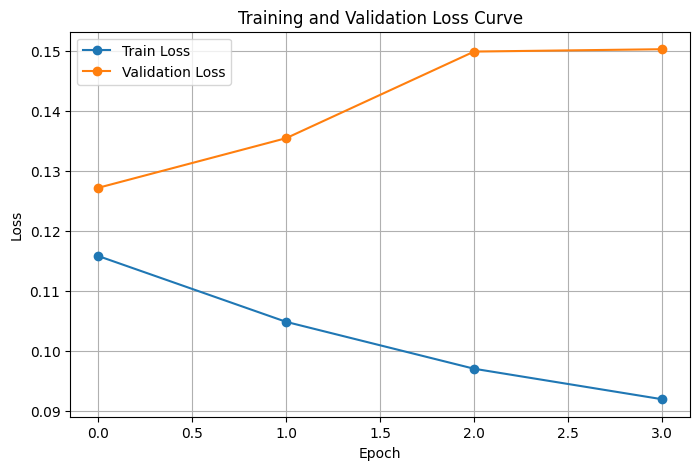

Loss curve saved to: /content/gpt-from-scratch-cyber-ar/results/plots/pretraining_loss.png


In [ ]:
# ============================================
# Cell 8: Plot Loss Curve
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')

plt.title("Training and Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

loss_plot_path = ROOT / "results" / "plots" / "pretraining_loss.png"
plt.savefig(loss_plot_path, bbox_inches="tight")
plt.show()

print("Loss curve saved to:", loss_plot_path)

In [ ]:
# ============================================
# Cell 9: Text Generation Demo
# ============================================

@torch.no_grad()
def generate_text(prompt, max_new_tokens=200):
    model.eval()

    input_ids = tokenizer.encode(prompt)
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

    output_ids = model.generate(input_tensor, max_new_tokens=max_new_tokens)
    output_text = tokenizer.decode(output_ids[0].tolist())

    return output_text


prompts = [
    "الأمن السيبراني مهم لأنه",
    "سؤال: ما هو التصيد الاحتيالي؟ جواب:",
    "لحماية الشبكات يجب"
]

generated_results = []

for p in prompts:
    generated_text = generate_text(p, max_new_tokens=150)
    generated_results.append({
        "prompt": p,
        "generation": generated_text
    })

    print("=" * 100)
    print("Prompt:", p)
    print("Generated Text:")
    print(generated_text)
    print()


generation_path = ROOT / "results" / "sample_generations" / "pretraining_generations.json"

with open(generation_path, "w", encoding="utf-8") as f:
    json.dump(generated_results, f, ensure_ascii=False, indent=2)

print("Generated samples saved to:", generation_path)

Prompt: الأمن السيبراني مهم لأنه
Generated Text:
الأمن السيبراني مهم لأنهامج الفدية مزيفة إلى النسخ الاحتياطية.
مركز العمليات الأمنية يراقب الخوادم من خلال ضوابط تقنية وإجرائية، ويمكن استخدام IDS للمساعدة في كشف تنفيذ أوامر

Prompt: سؤال: ما هو التصيد الاحتيالي؟ جواب:
Generated Text:
سؤال: ما هو التصيد الاحتيالي؟ جواب: التصيد الاحتيالي أسلوب خداعي يهدف إلى سرقة المعلومات الحساسة عبر رسائل أو صفحات مزيفة.
إدارة الثغرات يعزز الشبكات الداخلية من خلال ضوابط تقنية وإجرائ

Prompt: لحماية الشبكات يجب
Generated Text:
لحماية الشبكات يجب الداخلية من خلال ضوابط تقنية وإجرائية، ويمكن استخدام SIEM للمساعدة في كشف سرقة كلمات المرور وتقليل أثره.
التوعية الأمنية يحسن سرية البيانات من خلال ض

Generated samples saved to: /content/gpt-from-scratch-cyber-ar/results/sample_generations/pretraining_generations.json


In [ ]:
# ============================================
# Cell 10: Prepare SFT data + Fine-tuning
# ============================================

import math
import json
import torch
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# 1) Read SFT JSONL and convert to text format
# -----------------------------
sft_texts = []

with open(sft_path, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)

        sample_text = (
            f"التعليمات: {obj['instruction']}\n"
            f"المدخل: {obj['input']}\n"
            f"الإجابة: {obj['output']}\n"
        )

        sft_texts.append(sample_text)

full_sft_text = "\n".join(sft_texts)

print("Number of SFT records:", len(sft_texts))
print("First SFT sample:\n")
print(sft_texts[0][:500])

# -----------------------------
# 2) Encode SFT text
# -----------------------------
sft_ids = tokenizer.encode(full_sft_text)

print("\nTotal SFT tokens:", len(sft_ids))

# Split train / validation
sft_split_idx = int(0.9 * len(sft_ids))
sft_train_ids = sft_ids[:sft_split_idx]
sft_val_ids = sft_ids[sft_split_idx:]

print("SFT train tokens:", len(sft_train_ids))
print("SFT val tokens:", len(sft_val_ids))

# -----------------------------
# 3) Dataset class for SFT
# -----------------------------
class SFTDataset(Dataset):
    def __init__(self, ids, block_size):
        self.ids = ids
        self.block_size = block_size

    def __len__(self):
        return len(self.ids) - self.block_size

    def __getitem__(self, idx):
        chunk = self.ids[idx: idx + self.block_size + 1]
        x = torch.tensor(chunk[:-1], dtype=torch.long)
        y = torch.tensor(chunk[1:], dtype=torch.long)
        return x, y

sft_train_dataset = SFTDataset(sft_train_ids, BLOCK_SIZE)
sft_val_dataset = SFTDataset(sft_val_ids, BLOCK_SIZE)

sft_train_loader = DataLoader(sft_train_dataset, batch_size=16, shuffle=True, drop_last=True)
sft_val_loader = DataLoader(sft_val_dataset, batch_size=16, shuffle=False, drop_last=True)

print("SFT train samples:", len(sft_train_dataset))
print("SFT validation samples:", len(sft_val_dataset))

# -----------------------------
# 4) Fine-tuning loop
# -----------------------------
FT_EPOCHS = 3
FT_LEARNING_RATE = 1e-4

optimizer_ft = torch.optim.AdamW(model.parameters(), lr=FT_LEARNING_RATE)

sft_train_losses = []
sft_val_losses = []

def estimate_sft_loss(model, train_loader, val_loader, eval_iters=50):
    model.eval()

    train_loss_list = []
    val_loss_list = []

    with torch.no_grad():
        for i, (x, y) in enumerate(train_loader):
            if i >= eval_iters:
                break
            x, y = x.to(device), y.to(device)
            _, loss = model(x, y)
            train_loss_list.append(loss.item())

        for i, (x, y) in enumerate(val_loader):
            if i >= eval_iters:
                break
            x, y = x.to(device), y.to(device)
            _, loss = model(x, y)
            val_loss_list.append(loss.item())

    model.train()

    avg_train_loss = sum(train_loss_list) / len(train_loss_list)
    avg_val_loss = sum(val_loss_list) / len(val_loss_list)

    return avg_train_loss, avg_val_loss

for epoch in range(FT_EPOCHS):
    model.train()
    epoch_losses = []

    for step, (x, y) in enumerate(sft_train_loader):
        x, y = x.to(device), y.to(device)

        optimizer_ft.zero_grad()
        _, loss = model(x, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer_ft.step()

        epoch_losses.append(loss.item())

        if step % 100 == 0:
            print(f"SFT Epoch {epoch+1}/{FT_EPOCHS} | Step {step} | Batch Loss: {loss.item():.4f}")

    avg_train_loss, avg_val_loss = estimate_sft_loss(model, sft_train_loader, sft_val_loader)

    sft_train_losses.append(avg_train_loss)
    sft_val_losses.append(avg_val_loss)

    print(f"\nSFT Epoch {epoch+1} Finished")
    print(f"SFT Train Loss: {avg_train_loss:.4f}")
    print(f"SFT Val Loss:   {avg_val_loss:.4f}")
    print("-" * 50)

# Save finetuned model
finetuned_model_path = ROOT / "checkpoints" / "finetuned" / "gpt_finetuned.pt"
torch.save(model.state_dict(), finetuned_model_path)

print("Finetuned model saved to:", finetuned_model_path)

Number of SFT records: 260
First SFT sample:

التعليمات: اشرح المخاطر المرتبطة بـ
المدخل: عدم تحديث الأنظمة
الإجابة: عدم تحديث الأنظمة يبقي الثغرات المعروفة قابلة للاستغلال، ما يرفع احتمال الاختراق أو تنفيذ الشيفرة الضارة.


Total SFT tokens: 47824
SFT train tokens: 43041
SFT val tokens: 4783
SFT train samples: 42913
SFT validation samples: 4655
SFT Epoch 1/3 | Step 0 | Batch Loss: 5.0093
SFT Epoch 1/3 | Step 100 | Batch Loss: 0.7837
SFT Epoch 1/3 | Step 200 | Batch Loss: 0.2426
SFT Epoch 1/3 | Step 300 | Batch Loss: 0.1418
SFT Epoch 1/3 | Step 400 | Batch Loss: 0.1120
SFT Epoch 1/3 | Step 500 | Batch Loss: 0.1105
SFT Epoch 1/3 | Step 600 | Batch Loss: 0.1026
SFT Epoch 1/3 | Step 700 | Batch Loss: 0.0792
SFT Epoch 1/3 | Step 800 | Batch Loss: 0.0883
SFT Epoch 1/3 | Step 900 | Batch Loss: 0.0855
SFT Epoch 1/3 | Step 1000 | Batch Loss: 0.0875
SFT Epoch 1/3 | Step 1100 | Batch Loss: 0.0715
SFT Epoch 1/3 | Step 1200 | Batch Loss: 0.0760
SFT Epoch 1/3 | Step 1300 | Batch Loss: 0.0760
SFT Ep

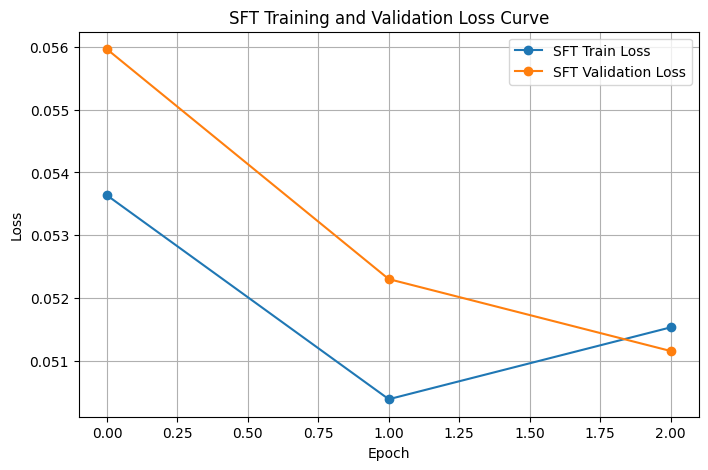

SFT loss curve saved to: /content/gpt-from-scratch-cyber-ar/results/plots/sft_loss.png

Evaluation Results:
pretraining_final_train_loss: 0.0920
pretraining_final_val_loss: 0.1503
pretraining_perplexity: 1.1621
sft_final_train_loss: 0.0515
sft_final_val_loss: 0.0512
sft_perplexity: 1.0525

Evaluation metrics saved to: /content/gpt-from-scratch-cyber-ar/results/evaluation_metrics.json

FINE-TUNED MODEL DEMO

----------------------------------------------------------------------------------------------------
Instruction: اشرح المفهوم التالي بلغة بسيطة
Input: التصيد الاحتيالي
Output:
التعليمات: اشرح المفهوم التالي بلغة بسيطة
المدخل: التصيد الاحتيالي
الإجابة: التصيد الاحتيالي محاولة خداع المستخدم للحصول على بيانات حساسة عبر رسالة أو صفحة مزيفة. أفضل حماية هي التحقق من المرسل والرابط وعدم مشاركة الرموز السر

----------------------------------------------------------------------------------------------------
Instruction: قارن بين المفهومين التاليين
Input: IDS و IPS
Output:
التعليمات: قارن بي

In [ ]:
# ============================================
# Cell 11: Evaluation + Fine-tuned Demo
# ============================================

import math
import matplotlib.pyplot as plt
import json

# -----------------------------
# 1) Plot SFT loss curve
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(sft_train_losses, marker='o', label='SFT Train Loss')
plt.plot(sft_val_losses, marker='o', label='SFT Validation Loss')

plt.title("SFT Training and Validation Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

sft_loss_plot_path = ROOT / "results" / "plots" / "sft_loss.png"
plt.savefig(sft_loss_plot_path, bbox_inches="tight")
plt.show()

print("SFT loss curve saved to:", sft_loss_plot_path)

# -----------------------------
# 2) Perplexity
# -----------------------------
def perplexity(loss_value):
    try:
        return math.exp(loss_value)
    except OverflowError:
        return float("inf")

eval_results = {
    "pretraining_final_train_loss": train_losses[-1],
    "pretraining_final_val_loss": val_losses[-1],
    "pretraining_perplexity": perplexity(val_losses[-1]),
    "sft_final_train_loss": sft_train_losses[-1],
    "sft_final_val_loss": sft_val_losses[-1],
    "sft_perplexity": perplexity(sft_val_losses[-1])
}

print("\nEvaluation Results:")
for k, v in eval_results.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

eval_results_path = ROOT / "results" / "evaluation_metrics.json"
with open(eval_results_path, "w", encoding="utf-8") as f:
    json.dump(eval_results, f, ensure_ascii=False, indent=2)

print("\nEvaluation metrics saved to:", eval_results_path)

# -----------------------------
# 3) Fine-tuned generation function
# -----------------------------
@torch.no_grad()
def ask_model(instruction, input_text="", max_new_tokens=180):
    model.eval()

    prompt = (
        f"التعليمات: {instruction}\n"
        f"المدخل: {input_text}\n"
        f"الإجابة:"
    )

    input_ids = tokenizer.encode(prompt)
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

    output_ids = model.generate(input_tensor, max_new_tokens=max_new_tokens)
    output_text = tokenizer.decode(output_ids[0].tolist())

    return output_text

# -----------------------------
# 4) Demo prompts after fine-tuning
# -----------------------------
demo_examples = [
    ("اشرح المفهوم التالي بلغة بسيطة", "التصيد الاحتيالي"),
    ("قارن بين المفهومين التاليين", "IDS و IPS"),
    ("أعطني خطوات عملية لحماية", "حساب بريد إلكتروني جامعي"),
    ("اكتب قائمة تحقق لفحص", "خادم ويب")
]

finetuned_outputs = []

print("\n" + "=" * 100)
print("FINE-TUNED MODEL DEMO")
print("=" * 100)

for instruction, input_text in demo_examples:
    output_text = ask_model(instruction, input_text, max_new_tokens=150)

    finetuned_outputs.append({
        "instruction": instruction,
        "input": input_text,
        "model_output": output_text
    })

    print("\n" + "-" * 100)
    print("Instruction:", instruction)
    print("Input:", input_text)
    print("Output:")
    print(output_text)

finetuned_outputs_path = ROOT / "results" / "sample_generations" / "finetuned_outputs.json"
with open(finetuned_outputs_path, "w", encoding="utf-8") as f:
    json.dump(finetuned_outputs, f, ensure_ascii=False, indent=2)

print("\nFine-tuned outputs saved to:", finetuned_outputs_path)

In [ ]:
# ============================================
# Cell 12: Generate README.md
# ============================================

readme_text = """
# Arabic Cybersecurity GPT From Scratch

## Project Overview
This project implements a small GPT-style language model built from scratch using PyTorch
for Arabic cybersecurity text generation and understanding.

## Objectives
- Build a Decoder-only Transformer from scratch
- Use Arabic cybersecurity data
- Perform pretraining on a TXT file
- Perform supervised fine-tuning on a JSONL file
- Evaluate the model using loss and text generation examples

## Dataset Summary

### 1) Pretraining Dataset
- File: data/pretrain/cyber_ar_pretrain.txt
- Encoding: UTF-8
- Domain: Arabic Cybersecurity
- Contains more than 1000 lines

### 2) SFT Dataset
- File: data/finetune/cyber_sft_data.jsonl
- Format: JSONL
- Contains more than 200 instruction-response samples

Example format:
{"instruction": "...", "input": "...", "output": "..."}

## Model Architecture
- Decoder-only Transformer
- Token Embedding
- Positional Embedding
- Multi-Head Self-Attention
- FeedForward Network
- LayerNorm
- Residual Connections

## Training
The model was trained in two stages:
1. Pretraining on raw Arabic cybersecurity text
2. Fine-tuning on instruction-response pairs

## Evaluation
The model was evaluated using:
- Training loss
- Validation loss
- Text generation examples

## Notes
This project is an educational implementation of a GPT-style language model
specialized in Arabic cybersecurity text.
"""

readme_path = ROOT / "README.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print("README saved to:", readme_path)

README saved to: /content/gpt-from-scratch-cyber-ar/README.md


In [ ]:
# ============================================
# Cell 13: Zip Project Folder
# ============================================

import shutil

zip_path = shutil.make_archive("/content/gpt-from-scratch-cyber-ar", "zip", ROOT)

print("Project zipped successfully!")
print("ZIP file location:")
print(zip_path)

Project zipped successfully!
ZIP file location:
/content/gpt-from-scratch-cyber-ar.zip


In [ ]:
# Bonus: Ask the model more cybersecurity questions

questions = [
    ("اشرح المفهوم التالي بلغة بسيطة", "التصيد الاحتيالي"),
    ("اشرح المفهوم التالي بلغة بسيطة", "التشفير"),
    ("قارن بين المفهومين التاليين", "IDS و IPS"),
    ("أعطني خطوات عملية لحماية", "الحسابات الإلكترونية"),
]

for instr, inp in questions:
    print("="*80)
    print("Instruction:", instr)
    print("Input:", inp)
    print("Model answer:\n")
    print(ask_model(instr, inp))

Instruction: اشرح المفهوم التالي بلغة بسيطة
Input: التصيد الاحتيالي
Model answer:

التعليمات: اشرح المفهوم التالي بلغة بسيطة
المدخل: التصيد الاحتيالي
الإجابة: التصيد الاحتيالي محاولة خداع المستخدم للحصول على بيانات حساسة عبر رسالة أو صفحة مزيفة. أفضل حماية هي التحقق من المرسل والرابط وعدم مشاركة الرموز السرية.

التعليمات: اشرح المخاطر ا
Instruction: اشرح المفهوم التالي بلغة بسيطة
Input: التشفير
Model answer:

التعليمات: اشرح المفهوم التالي بلغة بسيطة
المدخل: التشفير
الإجابة: التشفير يحول البيانات إلى صيغة غير مفهومة إلا لمن يملك المفتاح المناسب، وهو مهم لحماية سرية المعلومات أثناء النقل والتخزين.

التعليمات: اشرح المخاطر المرتبطة ب
المدخل: كلمات المرو
Instruction: قارن بين المفهومين التاليين
Input: IDS و IPS
Model answer:

التعليمات: قارن بين المفهومين التاليين
المدخل: IDS و IPS
الإجابة: IDS يكتشف النشاط الضار ويرسل تنبيهات، أما IPS فيكتشف الهجوم ويمنعه تلقائياً. الأول مناسب للرصد والثاني للرصد والمنع.

التعليمات: ما الإجراء المناسب عند اكتشاف
المدخل: ملف مشبوه
ال
Instruction: أعطني خط

In [ ]:
# ============================================
# Bonus: Free Text Generation Demo
# ============================================

prompts = [
    "الأمن السيبراني مهم لأنه",
    "من أهم طرق حماية الشبكات",
    "الهجمات السيبرانية يمكن أن تؤدي إلى",
]

for prompt in prompts:
    print("="*80)
    print("Prompt:", prompt)
    print("Generated text:\n")

    result = generate_text(prompt, max_new_tokens=120)

    print(result)
    print()

Prompt: الأمن السيبراني مهم لأنه
Generated text:

الأمن السيبراني مهم لأنه أكثر عرضة للوصول من المهاجم، أما غير المتصل فيمنح حماية أعلى ضد برامج الفدية.

التعليمات: اشرح المخاطر المرتبطة ب
المدخ

Prompt: من أهم طرق حماية الشبكات
Generated text:

من أهم طرق حماية الشبكات المرور الضعيفة تسهل التخمين أو الكسر وقد تؤدي إلى اختراق الحسابات وإعادة استخدام الاعتماديات عبر خدمات متعددة.

التعليم

Prompt: الهجمات السيبرانية يمكن أن تؤدي إلى
Generated text:

الهجمات السيبرانية يمكن أن تؤدي إلى اختراق الحسابات وإعادة استخدام الاعتماديات عبر خدمات متعددة.

التعليمات: قارن بين المفهومين التاليين
المدخل: النسخ الاح



In [ ]:
import shutil

zip_path = shutil.make_archive("/content/gpt-from-scratch-cyber-ar", "zip", ROOT)

print("Project zipped successfully!")
print(zip_path)

Project zipped successfully!
/content/gpt-from-scratch-cyber-ar.zip


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

Number of loss values: 4


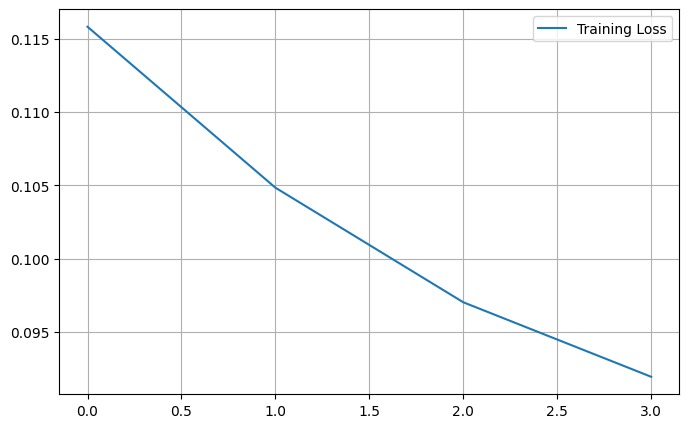

In [ ]:
import matplotlib.pyplot as plt

print("Number of loss values:", len(train_losses))

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(type(train_losses))
print("len(train_losses) =", len(train_losses))
print(train_losses[:10] if len(train_losses) > 0 else "empty")

<class 'list'>
len(train_losses) = 4
[0.11580726429820061, 0.1048429125547409, 0.09703528210520744, 0.09195833951234818]


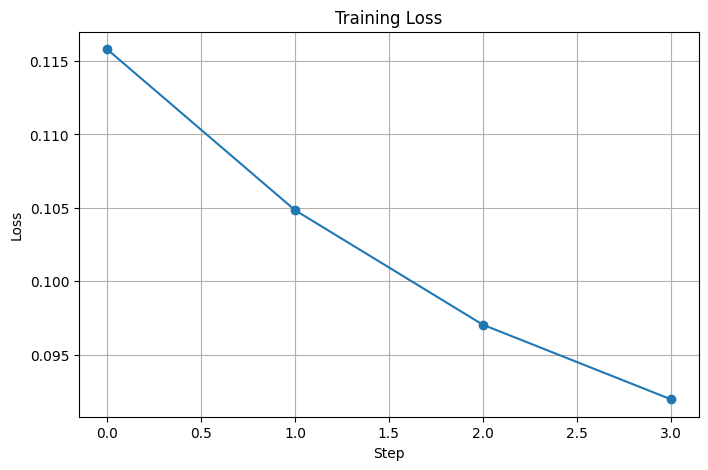

In [ ]:
import matplotlib.pyplot as plt

assert len(train_losses) > 0, "train_losses is empty"

plt.figure(figsize=(8,5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
def generate_text(prompt, max_new_tokens=120):
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

    output = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.8
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
def ask_model(instruction, input_text):
    prompt = f"التعليمات: {instruction}\nالمدخل: {input_text}\nالإجابة:"
    return generate_text(prompt, max_new_tokens=120)

print(ask_model("اشرح المفهوم التالي بلغة بسيطة", "التصيد الاحتيالي"))

التعليمات: اشرح المفهوم التالي بلغة بسيطة
المدخل: التصيد الاحتيالي
الإجابة: التصيد الاحتيالي محاولة خداع المستخدم للحصول على بيانات حساسة عبر رسالة أو صفحة مزيفة. أفضل حماية هي التحقق من المرسل و
